# Anchor miner testing notebook

In [1]:
import sys, os
import subprocess
sys.path.append(os.path.dirname(os.getcwd()))
from src.standartize_hlas import normalize_allele
import pandas as pd
import numpy as np
from src import AnchorMiner
from src.predict_anchors import predict_anchors
import tqdm
import re
import matplotlib.pyplot as plt
import sklearn
from Bio.PDB import PDBParser
from scipy.spatial.distance import cdist
from collections import defaultdict
import glob

## 1. Testing how much data will be excluded on a random dataset

In [6]:
df = pd.read_csv('../datasets/epitope_HLA_data.tsv', sep = '\t')[['Peptide', 'HLA_Allele']]
df.drop_duplicates(subset=['Peptide'], keep='first', inplace=True)

HLA_Alleles_standartized = [normalize_allele(i) for i in df['HLA_Allele'].tolist()]
df['HLA_Allele'] = HLA_Alleles_standartized

df = df.drop(df[df['Peptide'].isna()].index)
df = df.drop(df[df['HLA_Allele'].isna()].index)

anchors = []
anchors_masked = []
not_anchors_masked = []
excluded_combos = []
included_combos = []

for index,row in tqdm.tqdm(df.iterrows(), total = len(df)):
   try:
      anchors.append(predict_anchors(row['Peptide'], row['HLA_Allele'], False )['coords'])
      
      anchors_masked.append(''.join('X' if i in anchors[-1] else char for i, char in enumerate(row['Peptide'])))
      not_anchors_masked.append(''.join('X' if i not in anchors[-1] else char for i, char in enumerate(row['Peptide'])))
      included_combos.append(tuple([row['HLA_Allele'], len(row['Peptide'])]))
   except:
      anchors.append(np.nan)
      anchors_masked.append(np.nan)
      not_anchors_masked.append(np.nan)
      excluded_combos.append(tuple([row['HLA_Allele'], len(row['Peptide'])]))


df['anchors'] = anchors
df['anchors_masked'] = anchors_masked
df['not_anchors_masked'] = not_anchors_masked
    
display(df)




100%|██████████| 19367/19367 [00:47<00:00, 412.02it/s]


,Peptide,HLA_Allele,anchors,anchors_masked,not_anchors_masked
1,AAAAAAAAK,HLA-A03:01,"[0, 1, 2, 8]",XXXAAAAAX,AAAXXXXXK
3,AAAAAAAAL,HLA-B07:01,NaN,NaN,NaN
4,AAAAAAAALY,HLA-A29:02,"[0, 1, 2, 4, 5, 7, 8, 9]",XXXAXXAXXX,AAAXAAXALY
5,AAAAAIFVI,HLA-B51:01,"[1, 8]",AXAAAIFVX,XAXXXXXXI
6,AAAAGWQTL,HLA-A02:01,"[0, 1, 8]",XXAAGWQTX,AAXXXXXXL
...,...,...,...,...,...
62155,SSARSQSER,HLA-A11:01,"[0, 1, 2, 8]",XXXRSQSEX,SSAXXXXXR
62162,SMSMILVGV,HLA-A02:01,"[0, 1, 5, 8]",XXSMIXVGX,SMXXXLXXV
62171,YLVGNVCIL,HLA-A02:01,"[0, 1, 3, 5, 8]",XXVXNXCIX,YLXGXVXXL
62210,FLCLLIPGL,HLA-A02:01,"[0, 1, 5, 8]",XXCLLXPGX,FLXXXIXXL


In [7]:
print(f'Number of excluded rows: {df['anchors'].isna().sum()} out of {len(df)} ({round(df['anchors'].isna().sum() / len(df) * 100,1)}%)')
excluded_combos = set(excluded_combos)
print(f'Number of unique excluded HLA-len combos: {len(set(excluded_combos))}')
print('Among them:')
print(f'len(Epitope) < 9 (cannot predict binding): {sum(1 for _, num in excluded_combos if num < 9)}')
print(f'len(Epitope) > 9 (likely too low affinity to epitopes for netmhcpan detection): {sum(1 for _, num in excluded_combos if num > 9)}')
print('Other cases (Alleles currently not recognized by anchor miner due to limited PWM data):')
for i in excluded_combos:
    if i[1] == 9:
        print(i)

Number of excluded rows: 635 out of 19367 (3.3%)
Number of unique excluded HLA-len combos: 89
Among them:
len(Epitope) < 9 (cannot predict binding): 63
len(Epitope) > 9 (likely too low affinity to epitopes for netmhcpan detection): 16
Other cases (Alleles currently not recognized by anchor miner due to limited PWM data):
('HLA-B07:01', 9)
('HLA-B61:01', 9)
('HLA-A28:01', 9)
('HLA-B44:01', 9)
('HLA-A02:01', 9)
('HLA-A35:01', 9)
('HLA-A51:01', 9)
('HLA-B62:01', 9)
('HLA-A33:02', 9)
('HLA-A24:01', 9)


## 2. Testing on structural data

In [4]:
import pandas as pd
import numpy as np

 
STRUCT_DIR = '/home/aalarkin/Work/anchorminer/datasets/structural_data'



def process_structural_data(path):
    """
    Extract structural anchor positions from HLA contact frequency data.
 
    Args:
        path: Path to contacts CSV file.
        threshold: Mean HLA contact frequency threshold for anchor calling.
                   Recommended: 0.06 based on observed distribution gap.
 
    Returns:
        tuple: (peptide string, freqs dict, anchor positions list 0-indexed)
    """
    df = pd.read_csv(path)
    hla = df[df['region'].str.contains('hla_')]
    threshold = np.mean(hla['contact_freq'])
    #threshold = 0.05
 
    stats = (hla.groupby('pep_res')['contact_freq']
                .mean()
                .reset_index())

    stats['pos'] = stats['pep_res'].str[1:].astype(int) - 1
    stats['aa']  = stats['pep_res'].str[0]
    stats = stats.sort_values('pos').reset_index(drop=True)
    print(stats)
 
    peptide = ''.join(stats['aa'].tolist())
 
    freqs = {}
    for _, row in stats.iterrows():
        freqs[str(row['pos'])] = round(float(row['contact_freq']), 3)
 
    anchors = [int(row['pos']) 
               for _, row in stats.iterrows()
               if row['contact_freq'] >= threshold * 1.2 ]
 
    return peptide, freqs, anchors, stats, threshold
 

def compare_results(seq, anchors_true, anchors_pred):
    v_true = np.zeros(len(seq))
    v_pred = np.zeros(len(seq))

    for i in anchors_true:
        v_true[i] = 1

    for j in anchors_pred:
        v_pred[j] = 1

    jaccard = round(sklearn.metrics.jaccard_score(v_true, v_pred),3)
    f1 = round(sklearn.metrics.f1_score(v_true, v_pred),3)

    if v_true[0] == 1:
        f1_nozeros = round(sklearn.metrics.f1_score(v_true[1:], v_pred[1:]),3)
    else:
        f1_nozeros = f1

    return(jaccard,f1,f1_nozeros)

 
files = sorted(glob.glob(f'{STRUCT_DIR}/contacts_*.csv'))

 #ALLELES LIST FROM PDB

alleles = {
    '1ao7': 'HLA-A02:01',  # https://www.rcsb.org/structure/1AO7
    '1qrn': 'HLA-A02:01',  # https://www.rcsb.org/structure/1QRN (just HLA-A02 → A02:01)
    '2f53': 'HLA-A02:01',  # https://www.rcsb.org/structure/2F53 (just HLA-A → A02:01)
    '2vlj': 'HLA-A02:01',  # https://www.rcsb.org/structure/2VLJ
    '3hg1': 'HLA-A02:01',  # https://www.rcsb.org/structure/3HG1
    '3o4l': 'HLA-A02:01',  # https://www.rcsb.org/structure/3O4L (just HLA-A → A02:01)
    '3uts': 'HLA-A02:01',  # https://www.rcsb.org/structure/3UTS
    '4mji': 'HLA-B51:01', # https://www.rcsb.org/structure/4MJI
    '4qrp': 'HLA-B08:01',  # https://www.rcsb.org/structure/4QRP
    '5brz': 'HLA-A01:01',  # https://www.rcsb.org/structure/5BRZ (just A1 → A01:01)
    '5bs0': 'HLA-A01:01',  # https://www.rcsb.org/structure/5BS0 (just A1 → A01:01)
    '5hho': 'HLA-A02:01',  # https://www.rcsb.org/structure/5HHO
    '5hyj': 'HLA-A02:01',  # https://www.rcsb.org/structure/5HYJ (just A02 → A02:01)
    '6eqb': 'HLA-A02:01',  # https://www.rcsb.org/structure/6EQB (just A2 → A02:01)
    '6rp9': 'HLA-A02:01',  # https://www.rcsb.org/structure/6RP9
    '7dzn': 'HLA-B42:01',  # https://www.rcsb.org/structure/7DZN
}



structural_results = {}
for path in files:
    name = path.split('/')[-1].replace('contacts_', '').replace('.csv', '')
    peptide, freqs, anchors_struct, dataframe_per_struct, threshold = process_structural_data(path)
    structural_results[name] = {
        'peptide': peptide,
        'freqs': freqs,
        'anchors_struct': anchors_struct,
        'dataframe' : dataframe_per_struct,
        'threshold' : threshold
    }
   # print(f'{name}  {peptide}')
   # print(f'  freqs:   {freqs}')
   # print(f'  anchors struct: {anchors_struct}')
    try:
        am = predict_anchors(peptide, alleles[name], 'False')['coords']
    except:
        am = [1, len(peptide)-1]
        print('error')

    structural_results[name]['anchors_pred'] = am
    #print(f'  anchord pred: {am}')

val_df = pd.DataFrame(structural_results).transpose()[['peptide','anchors_struct', 'anchors_pred']]


jac = []
f1 = []
f1_nozeros = []

for index, row in val_df.iterrows():
    comp = compare_results(row['peptide'], row['anchors_struct'], row['anchors_pred'])
    jac.append(comp[0])
    f1.append(comp[1])
    f1_nozeros.append(comp[2])


val_df['jaccard'] = np.array(jac)
val_df['f1'] = f1
val_df['f1_nozeros'] = f1_nozeros


display(val_df)

print('jaccard',round(np.mean(val_df['jaccard']),3))
print('f1',round(np.mean(val_df['f1']),3))
print('f1, 0 residue ignored', round(np.mean(val_df['f1_nozeros']),3))

  pep_res  contact_freq  pos aa
0      L1      0.056149    0  L
1      L2      0.066749    1  L
2      F3      0.052649    2  F
3      G4      0.017487    3  G
4      Y5      0.013155    4  Y
5      P6      0.039019    5  P
6      V7      0.039619    6  V
7      Y8      0.049128    7  Y
8      V9      0.070532    8  V
  pep_res  contact_freq  pos aa
0      L1      0.061849    0  L
1      L2      0.070626    1  L
2      F3      0.056291    2  F
3      G4      0.018587    3  G
4      Y5      0.022832    4  Y
5      A6      0.028351    5  A
6      V7      0.037866    6  V
7      Y8      0.047897    7  Y
8      V9      0.076358    8  V
  pep_res  contact_freq  pos aa
0      S1      0.058990    0  S
1      L2      0.066038    1  L
2      L3      0.051310    2  L
3      M4      0.020357    3  M
4      W5      0.013368    4  W
5      I6      0.046059    5  I
6      T7      0.039562    6  T
7      Q8      0.046946    7  Q
8      C9      0.072003    8  C
  pep_res  contact_freq  pos aa
0      G

,peptide,anchors_struct,anchors_pred,jaccard,f1,f1_nozeros
1ao7,LLFGYPVYV,"[0, 1, 8]","[1, 3, 5, 8]",0.400,0.571,0.667
1qrn,LLFGYAVYV,"[0, 1, 2, 8]","[1, 3, 8]",0.400,0.571,0.667
2f53,SLLMWITQC,"[0, 1, 8]","[0, 1, 5]",0.500,0.667,0.500
2vlj,GILGFVFTL,"[1, 8]","[0, 1, 3, 5, 8]",0.400,0.571,0.571
3hg1,ELAGIGILTV,"[1, 8, 9]","[1, 2, 3, 9]",0.400,0.571,0.571
3o4l,GLCTLVAML,"[0, 1, 8]","[0, 1, 5, 8]",0.750,0.857,0.800
3uts,ALWGPDPAAA,"[0, 1, 2]","[0, 1, 2, 3, 4, 9]",0.500,0.667,0.571
4mji,TAFTIPSI,"[0, 2, 4]","[1, 7]",0.000,0.000,0.000
4qrp,HSKKKCDEL,"[0, 2, 4, 8]","[2, 4, 8]",0.750,0.857,1.000
5brz,EVDPIGHLY,"[0, 1, 8]","[1, 2, 8]",0.500,0.667,0.800


jaccard 0.486
f1 0.627
f1, 0 residue ignored 0.65


## Making plots for structural data validation

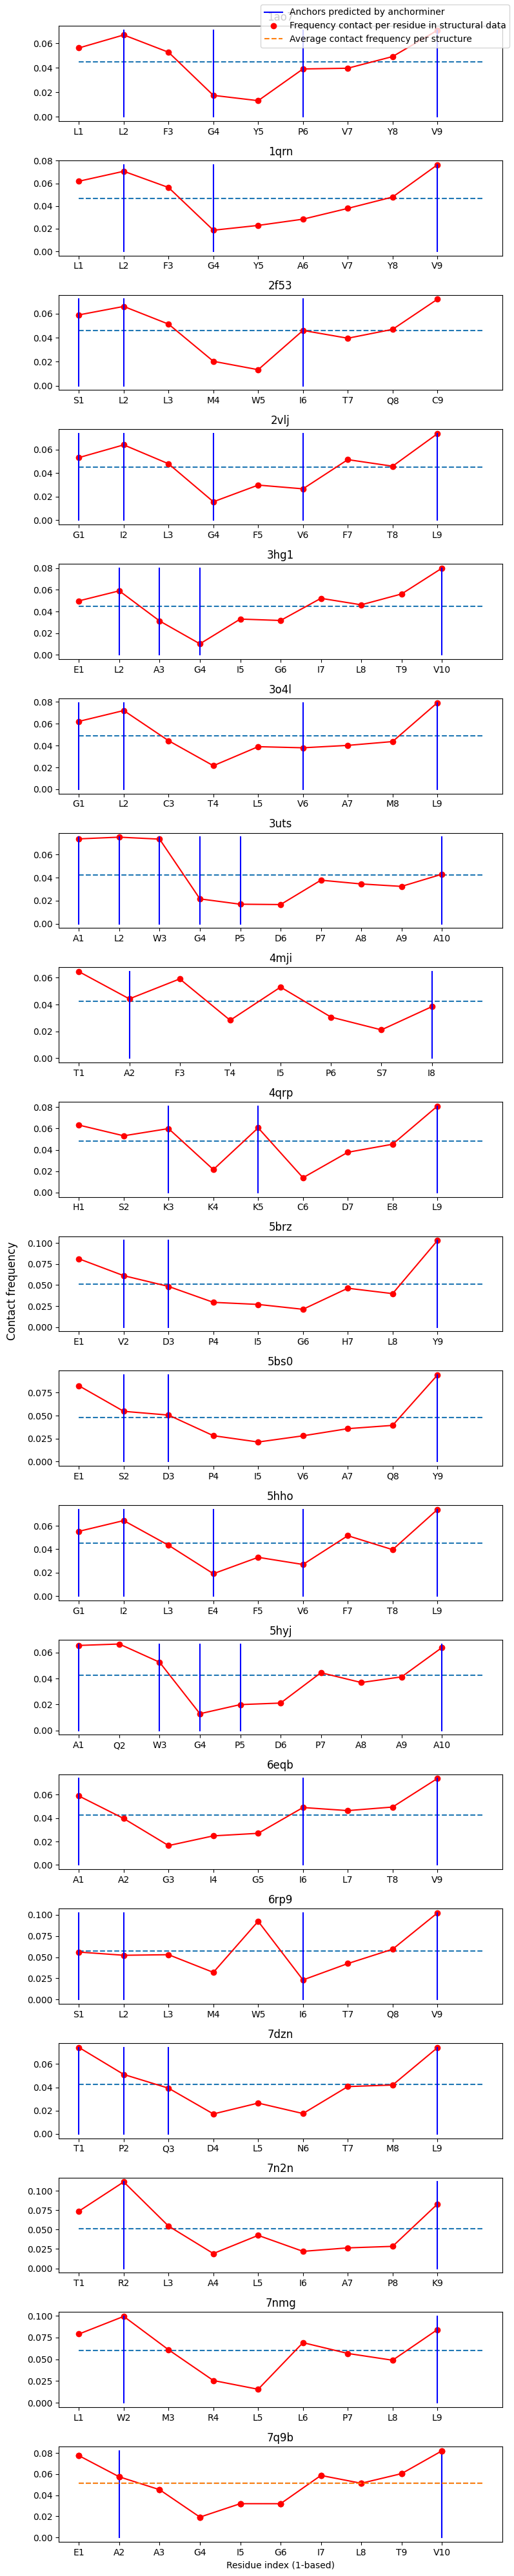

In [5]:
fig, ax = plt.subplots(len(val_df), figsize = (8,40))
plt.subplots_adjust(hspace=0.8, wspace=0.8)



subplot_id = 0
for index, row in val_df.iterrows():
    x = structural_results[index]['dataframe']['pos']
    y = structural_results[index]['dataframe']['contact_freq']
    lab = structural_results[index]['dataframe']['pep_res']
    threshold = structural_results[index]['threshold']
    predicted = row['anchors_pred']
    
    ax[subplot_id].plot([0, len(y)], [threshold, threshold], '--')
    ax[subplot_id].set_title(f'{index}')
    ax[subplot_id].plot(x,y, 'r')
    ax[subplot_id].plot(x,y, 'or')

    for i in predicted:
        x_i = [i,i]
        y_i = [0, max(y)]
        ax[subplot_id].plot(x_i, y_i, '-', color = 'blue')


    ax[subplot_id].set_xticks(x)
    ax[subplot_id].set_xticklabels(lab)



    if subplot_id == len(val_df) - 1:
        ax[subplot_id].set_xlabel('Residue index (1-based)')
        ax[subplot_id].plot(x_i, y_i, '-', color = 'blue', label = 'Anchors predicted by anchorminer')
        ax[subplot_id].plot(x,y, 'or', label = 'Frequency contact per residue in structural data')
        ax[subplot_id].plot([0, len(y)], [threshold, threshold], '--', label = 'Average contact frequency per structure')
    

   
    subplot_id += 1
#fig.suptitle('Comparison of residues frequency contact from structural data with anchorminer prediction')
#fig.supxlabel('Residue index (0-based)')
fig.supylabel('Contact frequency')
fig.legend(loc = 'upper right')
fig.tight_layout()




## Validating on static PDBs

In [5]:
PATH_TO_PDBS = '/home/aalarkin/Work/anchorminer/datasets/raw_structural_data'
#extracting only pdbs for structures that were studied before

pdbs = sorted(glob.glob(f'{PATH_TO_PDBS}/*'))
pdbs_final = []
#print(files)
for f in pdbs:
    name = f.lstrip(f'{PATH_TO_PDBS}/').rstrip('.pdb')
    name_dummy = '/home/aalarkin/Work/anchorminer/datasets/structural_data/contacts_' + name + '.csv'
    if name_dummy in files:
        pdbs_final.append(f)
       # print(name)
 #   else:
 #       print(f, 'is absent')



print(len(pdbs_final))
for i in pdbs_final:
    print(i)

16
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/1ao7.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/1qrn.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/2f53.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/2vlj.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/3hg1.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/3o4l.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/3uts.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/4mji.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/5brz.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/5bs0.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/5hho.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/5hyj.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/6rp9.pdb
/home/aalarkin/Work/anchorminer/datasets/raw_structural_data/7dzn.pdb
/home/aalarkin/Wo

### Manually extracting of HLA and epitope chains for each PDB record

In [6]:
chain_mappings = {
#pdb ID : [mhcI chain, epitope chains]
'1ao7' : ['A', 'C'],
'1qrn' : ['A', 'C'],
'2f53' : ['A', 'C'],
'2vlj' : ['A', 'C'],
'3hg1' : ['A', 'C'],
'3o4l' : ['A', 'C'],
'3uts' : ['A', 'C'],
'4mji' : ['A', 'C'],
'5brz' : ['A', 'C'],
'5bs0' : ['A', 'C'],
'5hho' : ['A', 'C'],
'5hyj' : ['A', 'C'],
'6rp9' : ['A', 'C'],
'7dzn' : ['A', 'C'],
'7n2n' : ['A', 'C'],
'7nmg' : ['A', 'C']
}





In [7]:
def get_chain_coords(pdb_file, chain_id):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('pMHC', pdb_file)
    coords_all = []
    residue_info = []
    for model in structure:
        for chain in model.get_chains():
            if chain.id == chain_id:
                for res in chain:
                    if res.id[0] == ' ':  # standard residue
                        for atom in res:
                            coords_all.append(atom.coord)
                            residue_info.append((res.resname, res.id[1]))
    return np.array(coords_all), residue_info


In [8]:
plot_data = dict()
aa_mapping = {
    'ALA': 'A',
    'ARG': 'R',
    'ASN': 'N',
    'ASP': 'D',
    'CYS': 'C',
    'GLN': 'Q',
    'GLU': 'E',
    'GLY': 'G',
    'HIS': 'H',
    'ILE': 'I',
    'LEU': 'L',
    'LYS': 'K',
    'MET': 'M',
    'PHE': 'F',
    'PRO': 'P',
    'SER': 'S',
    'THR': 'T',
    'TRP': 'W',
    'TYR': 'Y',
    'VAL': 'V'
}

for struct in chain_mappings:
    filename  = PATH_TO_PDBS + '/' + struct + '.pdb'
    hla_id, epitope_id = chain_mappings[struct][0], chain_mappings[struct][1]

    mhc_coords, mhc_res_info = get_chain_coords(filename, hla_id)
    pep_coords, pep_res_info = get_chain_coords(filename, epitope_id)

    plot_data[struct] = [[],[],[]]

    cutoff = 5
    contacts = []  # list of (pep_res, mhc_res, distance)

    dist_matrix = cdist(pep_coords, mhc_coords)
    rows, cols = np.where(dist_matrix <= cutoff)

    for i, j in zip(rows, cols):
        pep_res = pep_res_info[i]
        mhc_res = mhc_res_info[j]
        dist = dist_matrix[i, j]
        contacts.append((pep_res, mhc_res, dist))

        res = aa_mapping[pep_res[0]] + str(pep_res[1])

        if res not in plot_data[struct][2]:
            plot_data[struct][2].append(res)


    pep_contact_counts = defaultdict(int)
    pep_contact_distances = defaultdict(list)

    for pep_res, mhc_res, dist in contacts:
        pos = pep_res[1]  
        pep_contact_counts[pos] += 1
        pep_contact_distances[pos].append(dist)

    plot_data[struct][0] = list(np.array(list(pep_contact_counts.keys())) - 1)
    plot_data[struct][1] = list(pep_contact_counts.values())
    
    sorted_positions = sorted(pep_contact_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"Peptide positions with most MHC contacts for {struct}:")
    for pos, count in sorted_positions:
        avg_dist = np.mean(pep_contact_distances[pos])
        print(f"Position {pos-1}: {count} contacts, avg distance {avg_dist:.2f} Å") #REINDEXED POSITION TO 0-BASED INDEXING! CAREFUL



    print('=' * 50)


Peptide positions with most MHC contacts for 1ao7:
Position 0: 112 contacts, avg distance 4.30 Å
Position 8: 112 contacts, avg distance 4.31 Å
Position 2: 106 contacts, avg distance 4.39 Å
Position 1: 98 contacts, avg distance 4.31 Å
Position 7: 80 contacts, avg distance 4.39 Å
Position 5: 31 contacts, avg distance 4.54 Å
Position 6: 30 contacts, avg distance 4.43 Å
Position 4: 14 contacts, avg distance 4.53 Å
Position 3: 3 contacts, avg distance 4.50 Å
Peptide positions with most MHC contacts for 1qrn:
Position 2: 112 contacts, avg distance 4.30 Å
Position 8: 111 contacts, avg distance 4.23 Å
Position 0: 110 contacts, avg distance 4.25 Å
Position 1: 106 contacts, avg distance 4.27 Å
Position 7: 71 contacts, avg distance 4.32 Å
Position 6: 30 contacts, avg distance 4.46 Å
Position 4: 17 contacts, avg distance 4.37 Å
Position 5: 15 contacts, avg distance 4.59 Å
Position 3: 4 contacts, avg distance 4.55 Å
Peptide positions with most MHC contacts for 2f53:
Position 1: 115 contacts, avg di

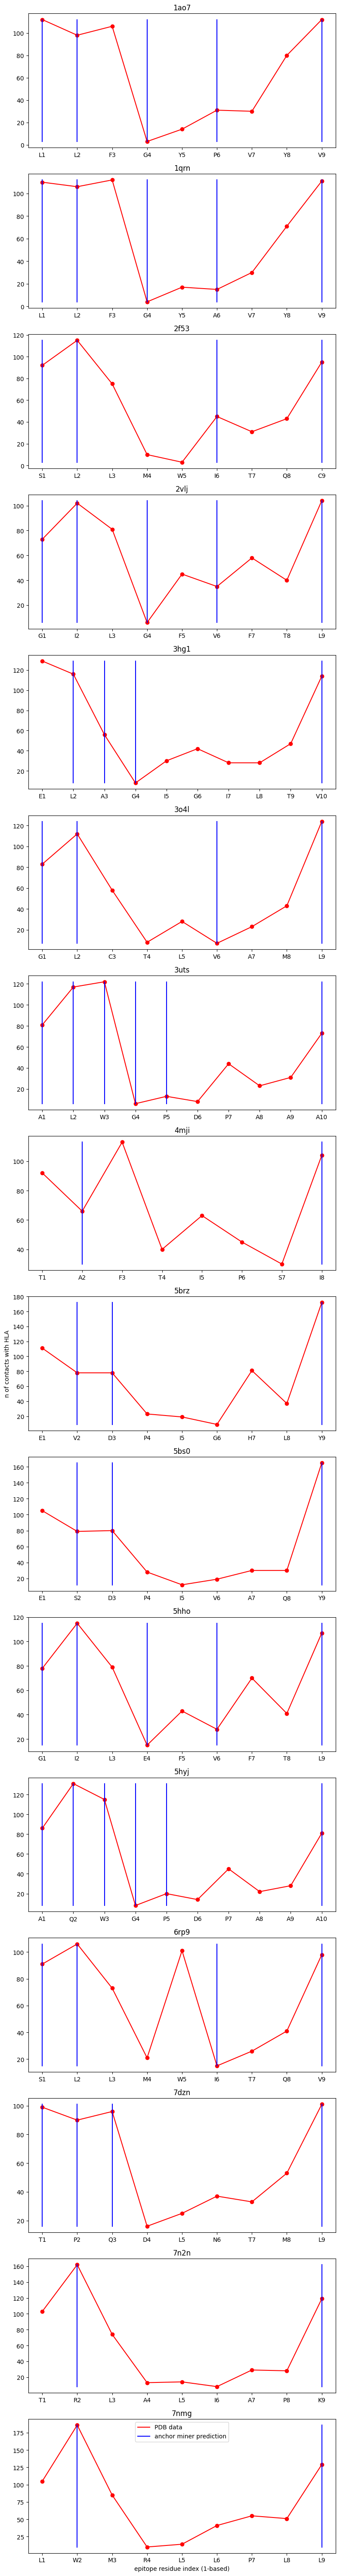

In [9]:
#Plotting only pdb data

fig, ax = plt.subplots(len(chain_mappings), figsize = (8,60))
plt.subplots_adjust(hspace=0.8, wspace=0.8)


subplot_id = 0
for i in chain_mappings:

    x,y, ticks = plot_data[i]




    if subplot_id == len(chain_mappings) // 2:
        ax[subplot_id].set_ylabel('n of contacts with HLA')

    if subplot_id == len(chain_mappings) - 1:
        ax[subplot_id].plot(x,y, 'r', label = 'PDB data')
        ax[subplot_id].plot(x,y, 'or')
        ax[subplot_id].set_xlabel('epitope residue index (1-based)')


    else:   
        ax[subplot_id].plot(x,y, 'r')
        ax[subplot_id].plot(x,y, 'or')


    ax[subplot_id].set_title(i)
    ax[subplot_id].set_xticks(x,ticks)

    predicted_anchors = val_df.loc[i]['anchors_pred']
    
    for j in predicted_anchors:
        x_i = [j,j]
        y_i = [min(y), max(y)]
        

        if j == predicted_anchors[-1] and subplot_id == len(chain_mappings) - 1:
            ax[subplot_id].plot(x_i,y_i, 'b', label = 'anchor miner prediction')
            ax[subplot_id].legend()

        else:
            ax[subplot_id].plot(x_i,y_i, 'b')
            
            



    


    subplot_id += 1


fig.tight_layout()


## Testing mouse MHCI anchor prediction

In [8]:
mouse_epitopes = [
    "SYVPSAEQIL",
    "ASNENMETM",
    "ASNENMETM",
    "FSHHNIIRL",
    "VVSKYKPM",
    "YVNTNMG"]

mouse_mhcs = [
    "H:2:Kd",
    "H:2:Db",
    "H:2:Db",
    "H:2:Db",
    "H:2:Kb",
    "H:2:Kd"
]


df = pd.DataFrame(data={'antigen.epitope' : mouse_epitopes, 'mhc' : mouse_mhcs})
                  
display(df)

anchors = []
anchors_masked = []
not_anchors_masked = []
excluded_combos = []
included_combos = []


for index,row in tqdm.tqdm(df.iterrows(), total = len(df)):
   try:
      anchors.append(predict_anchors(row['antigen.epitope'], row['mhc'], False )['coords'])
      
      anchors_masked.append(''.join('X' if i in anchors[-1] else char for i, char in enumerate(row['antigen.epitope'])))
      not_anchors_masked.append(''.join('X' if i not in anchors[-1] else char for i, char in enumerate(row['antigen.epitope'])))
      included_combos.append(tuple([row['mhc'], len(row['antigen.epitope'])]))
   except:
      anchors.append([1, len(row['antigen.epitope']) - 1])
      anchors_masked.append(''.join('X' if i in anchors[-1] else char for i, char in enumerate(row['antigen.epitope'])))
      not_anchors_masked.append(''.join('X' if i not in anchors[-1] else char for i, char in enumerate(row['antigen.epitope'])))

      excluded_combos.append(tuple([row['mhc'], len(row['antigen.epitope'])]))


df['anchors'] = anchors
df['anchors_masked'] = anchors_masked
df['not_anchors_masked'] = not_anchors_masked
    
display(df)


,antigen.epitope,mhc
0,SYVPSAEQIL,H:2:Kd
1,ASNENMETM,H:2:Db
2,ASNENMETM,H:2:Db
3,FSHHNIIRL,H:2:Db
4,VVSKYKPM,H:2:Kb
5,YVNTNMG,H:2:Kd


100%|██████████| 6/6 [00:00<00:00, 168.82it/s]


,antigen.epitope,mhc,anchors,anchors_masked,not_anchors_masked
0,SYVPSAEQIL,H:2:Kd,"[0, 1, 9]",XXVPSAEQIX,SYXXXXXXXL
1,ASNENMETM,H:2:Db,"[0, 1, 4, 8]",XXNEXMETX,ASXXNXXXM
2,ASNENMETM,H:2:Db,"[0, 1, 4, 8]",XXNEXMETX,ASXXNXXXM
3,FSHHNIIRL,H:2:Db,"[0, 1, 4, 8]",XXHHXIIRX,FSXXNXXXL
4,VVSKYKPM,H:2:Kb,"[0, 1, 4, 7]",XXSKXKPX,VVXXYXXM
5,YVNTNMG,H:2:Kd,"[1, 6]",YXNTNMX,XVXXXXG
